# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic. 


In [11]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

import pandas as pd
import matplotlib.pyplot as plt

In [12]:
netflix_pcap = PCAP('/Users/domi/Desktop/CMSC25422/CMSC-25422/docs/notebooks/data/netflix.pcap')

### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [13]:
netflix_pcap.pcap2pandas()
netflix_df = netflix_pcap.df

In [14]:
netflix_df.head()
netflix_df_dns = netflix_df[netflix_df['is_dns'] == False] # once connection is established, DNS is no longer needed unless the connection breaks
# non-DNS traffic is the main transmitter of video
print ("Original Data: ", netflix_df.shape, "\nPartioned Data: ", netflix_df_dns.shape)


Original Data:  (141471, 18) 
Partioned Data:  (141303, 18)


### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [15]:
import numpy as np

# Split flows into 10-second windows
netflix_pcap.pcap2flows(interval=10.0)
netflix_pcap.q_interval = 0.9  # flow2features() reads this even with an explicit interval

# --- Feature 1: bytes_rate (bytes/sec) per window, via netml's STATS extractor ---
# STATS = [duration, pkts_rate, bytes_rate, mean, std, q1, q2, q3, min, max, num_pkts, num_bytes]
netflix_pcap.flow2features(feat_type='STATS')
bytes_rate = [stats[2] for stats in netflix_pcap.features]

# --- Feature 2: IAT-based burst detection per window ---
# A "burst" is a run of packets whose inter-arrival times stay below gap_threshold;
# a gap >= gap_threshold marks the boundary between bursts (idle periods between segment fetches).
BURST_GAP_THRESHOLD = 0.1  # seconds

def burst_features(pkt_times, gap_threshold=BURST_GAP_THRESHOLD):
    pkt_times = sorted(pkt_times)
    if len(pkt_times) < 2:
        return {'burst_count': 1 if pkt_times else 0, 'mean_iat': 0.0, 'mean_burst_gap': 0.0}

    iats = np.diff(pkt_times)
    gap_mask = iats > gap_threshold
    burst_count = int(np.sum(gap_mask)) + 1
    gaps = iats[gap_mask]

    return {
        'burst_count': burst_count,
        'mean_iat': float(np.mean(iats)),
        'mean_burst_gap': float(np.mean(gaps)) if len(gaps) > 0 else 0.0,
    }

burst_rows = []
for fid, pkts in netflix_pcap.flows:
    pkt_times = [float(pkt.time) for pkt in pkts]
    burst_rows.append(burst_features(pkt_times))

# --- Assemble the feature vector, one row per (flow, 10s window) ---
fid_index = pd.MultiIndex.from_tuples(
    netflix_pcap.fids, names=['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol']
)

netflix_features_df = pd.DataFrame(burst_rows, index=fid_index)
netflix_features_df.insert(0, 'bytes_rate', bytes_rate)

netflix_features_df.head()


bytes_rate  \
src_ip        dst_ip         src_port dst_port protocol               
192.168.43.72 172.217.18.195 58443    443      6          93.529895   
              216.58.209.228 58444    443      6         574.213714   
                             58445    443      6         256.004241   
              172.217.18.195 58446    443      6         256.553725   
                             58447    443      6         213.689947   

                                                         burst_count  \
src_ip        dst_ip         src_port dst_port protocol                
192.168.43.72 172.217.18.195 58443    443      6                   6   
              216.58.209.228 58444    443      6                  16   
                             58445    443      6                   3   
              172.217.18.195 58446    443      6                   3   
                             58447    443      6                   8   

                                                         mean_iat  \
src_ip        dst_ip         src_port dst_port protocol             
192.168.43.72 172.217.18.195 58443    443      6         1.041961   
              216.58.209.228 58444    443      6         0.151423   
                             58445    443      6         0.410149   
              172.217.18.195 58446    443      6         0.409271   
                             58447    443      6         0.493998   

                                                         mean_burst_gap  
src_ip        dst_ip         src_port dst_port protocol                  
192.168.43.72 172.217.18.195 58443    443      6               2.276572  
              216.58.209.228 58444    443      6               0.505887  
                             58445    443      6               0.410149  
              172.217.18.195 58446    443      6               0.409271  
                             58447    443      6               1.110313

**Write a brief justification for the features that you have chosen.**

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

In [16]:
from netml.pparser.parser import _get_SAMP_NUM

# --- Feature 3: segment download rate, via netml's SAMP_NUM windows ---
# SAMP_NUM splits each (already 10s) flow window into fixed-length sub-windows and
# counts packets per sub-window. A sub-window with more than SEGMENT_PKT_THRESHOLD
# packets indicates an active download burst (a video segment fetch) rather than
# idle/ACK traffic; counting these active sub-windows and dividing by the flow
# window's duration gives a segments/sec rate.
SAMP_SUBWINDOW = 1.0        # seconds per SAMP sub-window
SEGMENT_PKT_THRESHOLD = 5   # packets in a sub-window to count it as an active segment download

samp_num_features, samp_fids = _get_SAMP_NUM(netflix_pcap.flows, sampling_rate=SAMP_SUBWINDOW)
assert samp_fids == netflix_pcap.fids  # SAMP preserves flow order, so it aligns with netflix_features_df

segments_download_rate = []
for (fid, pkts), samp in zip(netflix_pcap.flows, samp_num_features):
    pkt_times = [float(pkt.time) for pkt in pkts]
    duration = max(pkt_times) - min(pkt_times) if len(pkt_times) > 1 else 0.0
    num_segments = sum(1 for count in samp if count > SEGMENT_PKT_THRESHOLD)
    segments_download_rate.append(num_segments / duration if duration > 0 else 0.0)

netflix_features_df['segments_download_rate'] = segments_download_rate

netflix_features_df.head()


bytes_rate  \
src_ip        dst_ip         src_port dst_port protocol               
192.168.43.72 172.217.18.195 58443    443      6          93.529895   
              216.58.209.228 58444    443      6         574.213714   
                             58445    443      6         256.004241   
              172.217.18.195 58446    443      6         256.553725   
                             58447    443      6         213.689947   

                                                         burst_count  \
src_ip        dst_ip         src_port dst_port protocol                
192.168.43.72 172.217.18.195 58443    443      6                   6   
              216.58.209.228 58444    443      6                  16   
                             58445    443      6                   3   
              172.217.18.195 58446    443      6                   3   
                             58447    443      6                   8   

                                                         mean_iat  \
src_ip        dst_ip         src_port dst_port protocol             
192.168.43.72 172.217.18.195 58443    443      6         1.041961   
              216.58.209.228 58444    443      6         0.151423   
                             58445    443      6         0.410149   
              172.217.18.195 58446    443      6         0.409271   
                             58447    443      6         0.493998   

                                                         mean_burst_gap  \
src_ip        dst_ip         src_port dst_port protocol                   
192.168.43.72 172.217.18.195 58443    443      6               2.276572   
              216.58.209.228 58444    443      6               0.505887   
                             58445    443      6               0.410149   
              172.217.18.195 58446    443      6               0.409271   
                             58447    443      6               1.110313   

                                                         segments_download_rate  
src_ip        dst_ip         src_port dst_port protocol                          
192.168.43.72 172.217.18.195 58443    443      6                       0.087248  
              216.58.209.228 58444    443      6                       0.559662  
                             58445    443      6                       0.000000  
              172.217.18.195 58446    443      6                       0.000000  
                             58447    443      6                       0.126519

## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

For this part of the assignment, you will need two pickle files, which we provide for you by running the code below:

```

!gdown 'https://drive.google.com/uc?id=1N-Cf4dJ3fpak_AWgO05Fopq_XPYLVqdS' -O netflix_session.pkl
!gdown 'https://drive.google.com/uc?id=1PHvEID7My6VZXZveCpQYy3lMo9RvMNTI' -O video_dataset.pkl

```

### Load the File

Load the video dataset pickle file.

In [ ]:
video_dataset_df = pd.read_pickle('/Users/domi/Desktop/CMSC25422/CMSC-25422/docs/assignments/assn_1_data/netflix_dataset.pkl.xz')
video_dataset_df.head()

### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [18]:
valid_resolutions = [240, 360, 480, 720, 1080]
video_dataset_df = video_dataset_df[video_dataset_df['resolution'].isin(valid_resolutions)]

print(video_dataset_df.shape)
video_dataset_df['resolution'].value_counts()

(49748, 251)


resolution
480.0     29486
720.0      9457
1080.0     4628
360.0      4476
240.0      1701
Name: count, dtype: int64

2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [19]:
unhelpful_columns = [
    'index',                  # constant across every row; carries no information
    'service',                 # constant ('netflix' for every row); carries no information
    'session_id',               # unique per capture session; won't generalize to new sessions
    'deployment_session_id',    # unique per capture session; won't generalize to new sessions
    'home_id',                  # identifies the lab/home where the capture was taken
    'video_id',                 # identifies the specific video; won't generalize to new videos
    'absolute_timestamp',       # bookkeeping timestamp tied to this specific capture
    'relative_timestamp',       # bookkeeping timestamp tied to this specific capture
    'chunk_start_time',         # bookkeeping timestamp tied to this specific capture
    'chunk_end_time',           # bookkeeping timestamp tied to this specific capture
    'quality',                  # deterministic function of resolution -- leaks the label
]

video_dataset_df = video_dataset_df.drop(columns=unhelpful_columns)
video_dataset_df.shape

(49748, 240)

**Briefly explain why you removed those columns.**

We removed columns that either carry no predictive information or would let the model "cheat":

- **`index`** and **`service`** are constant for every row (the latter is always `'netflix'`), so they cannot help distinguish examples.
- **`session_id`**, **`deployment_session_id`**, **`home_id`**, and **`video_id`** are identifiers tied to a specific capture session, home network, or video title. A model trained on these would memorize particular sessions/videos rather than learning traffic patterns that generalize to *new* sessions and videos.
- **`absolute_timestamp`**, **`relative_timestamp`**, **`chunk_start_time`**, and **`chunk_end_time`** just record when a chunk was captured during this specific experiment; they don't describe any property of the traffic itself.
- **`quality`** is a direct, deterministic function of `resolution` (the label we're trying to predict) — `bad`/`good`/`unknown` is just a binned version of the same information — so keeping it would leak the answer.

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [20]:
from sklearn.model_selection import train_test_split

# '10_EWMA_chunksizes' holds a nested array per row rather than a scalar value,
# so it isn't usable as a feature without additional processing; drop it along
# with any rows still missing values (e.g. avg_flow_age).
model_df = video_dataset_df.drop(columns=['10_EWMA_chunksizes']).dropna()

X = model_df.drop(columns=['resolution'])
y = model_df['resolution']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
y_train.value_counts(normalize=True).sort_index()

Train: (38424, 238), Test: (9607, 238)


resolution
240.0     0.033677
360.0     0.090725
480.0     0.587888
720.0     0.191495
1080.0    0.096216
Name: proportion, dtype: float64

### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Random forest: handles the mix of feature scales and distributions in this
# dataset well, requires no feature scaling, and gives a strong baseline for
# multi-class classification.
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.9532632455501197

### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [22]:
from sklearn.model_selection import RandomizedSearchCV

# Minimal tuning: a small randomized search over a handful of the most
# impactful random forest hyperparameters, using 3-fold cross-validation.
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=6,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV F1 (macro):", search.best_score_)

model = search.best_estimator_

Best params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': 30}
Best CV F1 (macro): 0.8848462963591016


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

Accuracy: 0.9511
F1 Score (macro): 0.8964


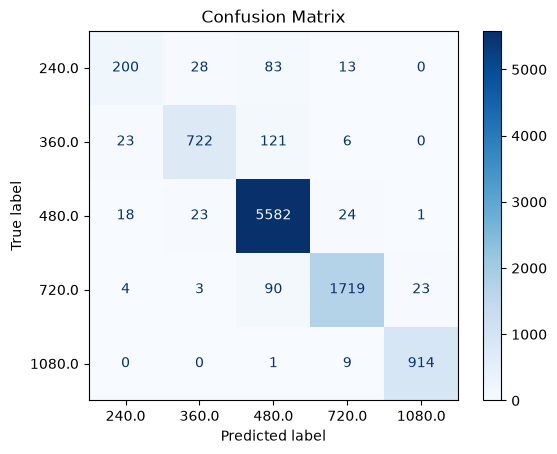

ROC AUC (macro, one-vs-rest): 0.9950


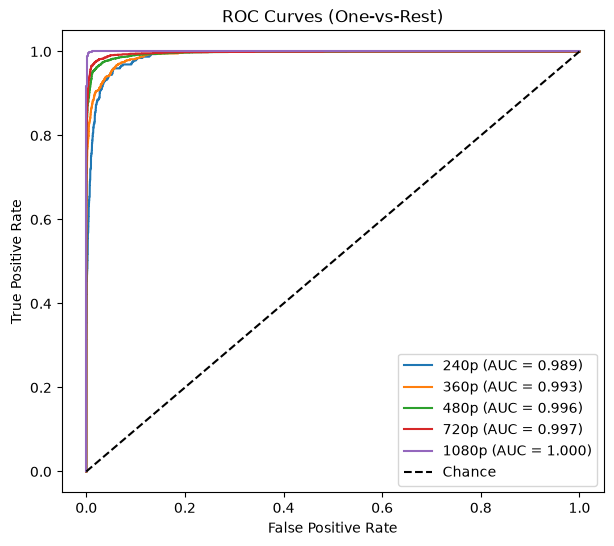

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# 2. F1 Score (macro-averaged across the 5 resolution classes)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1 Score (macro): {f1:.4f}")

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# 4. ROC / AUC (one-vs-rest, since this is a 5-class problem)
y_test_bin = label_binarize(y_test, classes=model.classes_)
roc_auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
print(f"ROC AUC (macro, one-vs-rest): {roc_auc:.4f}")

plt.figure(figsize=(7, 6))
for i, cls in enumerate(model.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'{int(cls)}p (AUC = {auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend()
plt.show()

## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.